##Iris-Species-Classification-KNN


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [7]:
df=pd.read_csv("Iris.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
df.isnull().sum()
df.drop("Unnamed: 32", axis=1, inplace=True, errors='ignore')
df.dropna(inplace=True)

In [10]:
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [11]:
X=df.drop("Species",axis=1)
y=df["Species"].map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2})

<Axes: xlabel='Species', ylabel='count'>

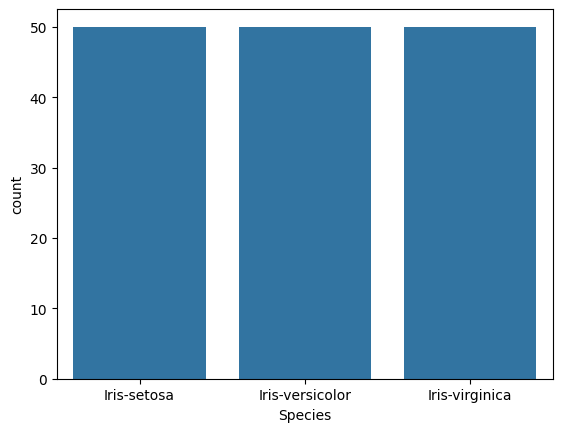

In [12]:
sns.countplot(x="Species",data=df)

In [22]:
#eğitim aşaması
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=50)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [23]:
#model aşaması knn
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

In [24]:
#başarı metrikleri
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion_matrix:",confusion_matrix(y_test,y_pred))
print("classification_report:",classification_report(y_test,y_pred))


accuracy: 1.0
confusion_matrix: [[14  0  0]
 [ 0 17  0]
 [ 0  0 14]]
classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



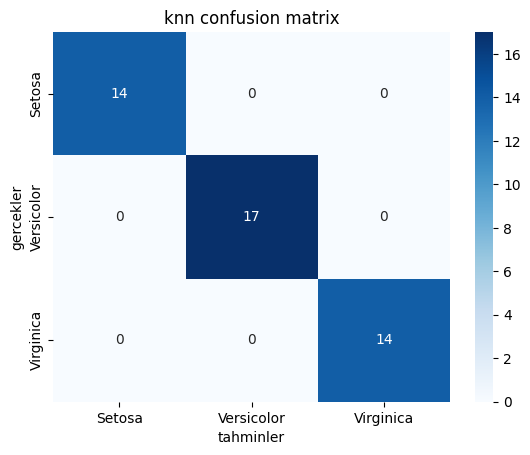

In [25]:
sinif_isimleri = ['Setosa', 'Versicolor', 'Virginica']
cm_knn=confusion_matrix(y_test,y_pred)
sns.heatmap(cm_knn,annot=True,fmt="d", cmap='Blues',xticklabels=sinif_isimleri,
            yticklabels=sinif_isimleri)
plt.title("knn confusion matrix")
plt.xlabel("tahminler")
plt.ylabel("gercekler")
plt.show()

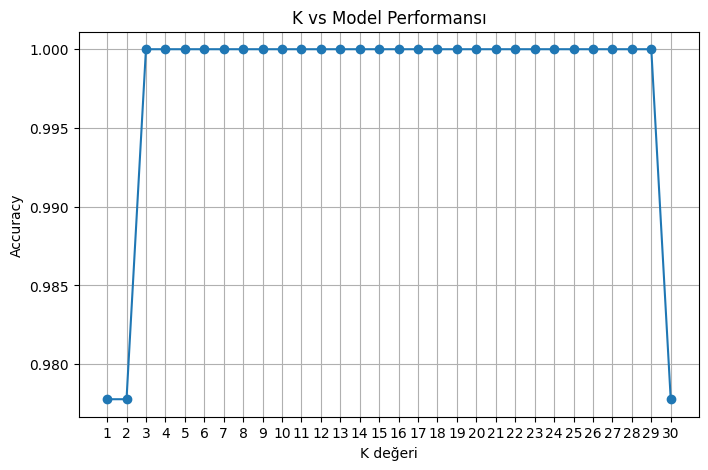

In [26]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K değeri")
plt.ylabel("Accuracy")
plt.title("K vs Model Performansı")
plt.xticks(k_values)
plt.grid(True)
plt.show()

“KNN modelinin performansı k değerine bağlı olarak değişmektedir. Küçük k değerlerinde model overfitting eğilimindeyken, büyük k değerlerinde underfitting görülmektedir.”

In [27]:
best_k = k_values[accuracies.index(max(accuracies))]
print("En iyi k:", best_k)

En iyi k: 3


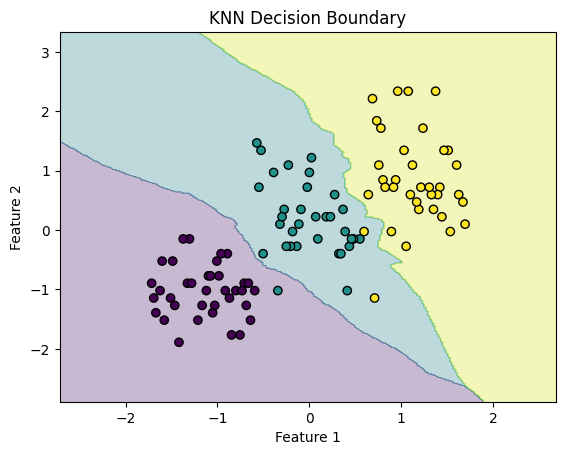

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# sadece 2 feature seçiyoruz (görselleştirme için şart)
X = X_train[:, :2]
y = y_train

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X, y)

# mesh grid oluştur
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# çizim
plt.contourf(xx, yy, Z, alpha=0.3)

# veri noktaları
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary")
plt.show()